##### API Gateways:

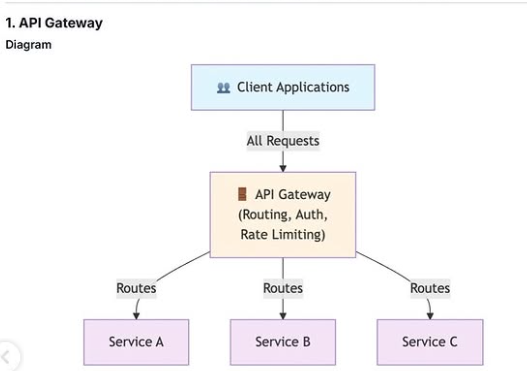

API Gateway is single entry point for the all client request. It act as a reverse proxy which routes to the corrcet backend service.
Instead of client calling the service directly it communicate through the API gateways.

##### Key responsibilities:
*   Request Routing
*   Authentication & Authorization
*   Rate limiting
*   Request/Response teansforamtion - Modifies request or repsonse as required.
*   Protocol Translation: Conversts between different protocols.
*   Load balancing: Distributes requests across multiple instance.

##### Benefits:
*   Centralized security and logging
*   Simplified client integration
* Service location transparency
* Reduce network calls

[Source]: https://medium.com/@upesh.jindal/build-your-own-api-gateway-using-fastapi-af4b905dbd27



-Interview:

API Gateway is a centralized entry point that manages routing, security, rate limiting, monitoring, caching, and communication between clients and backend microservices.

### Code:

      Client
         ↓
      API Gateway (8000)
         ├── /users/*  → User Service (8001)
         └── /orders/* → Order Service (8002)

In [ ]:
## User Service (8001)

from fastapi import FastAPI

app = FastAPI()

@app.get("/user/{user_id}")
def get_user(user_id:int):
    return {
        "service":"User Service",
        "user_id": user_id,
        "name": "Alice"
    }

In [2]:
## Order Service (8002)

from fastapi import FastAPI

app = FastAPI()

@app.get("/order/{order_id}")
def get_order(order_id:int):
    return{
        "service": "Order Service",
        "order_id": order_id,
        "amount": 500
    }

In [3]:
## Custom API gateways.
## In prod we use Nginx and other third part APIs.

from fastapi import FastAPI, Request, Response
import requests

app = FastAPI()

SERVICES = {
    "users" : "http://localhost:8001",
    "orders" : "http://localhost:8002"
}

@app.api_route(
    "/{service}/{path}",
    methods=["GET", "POST", "PUT", "PATCH", "DELETE"]
)
async def proxy(service: str, path:str, request: Request):

    if service not in SERVICES:
        return {"error": "Service Not Found"}

    target_url = f"{SERVICES[service]}/{path}"

    body = await request.body()

    header = dict(request.headers)

    param = request.query_params

    response = requests.request(
        method=request.method,
        url=target_url,
        headers=headers,
        params=params,
        data=body
    )

    return Response(
        content=response.content,
        status_code=response.status_code,
        headers=dict(response.headers)
    )

d:\python\AI\pynb\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


Add tracing headers

For debugging across microservices.

X-Request-ID: abc123



### Typical request lifecycle

      Client Request
            ↓
      API Gateway
            ↓
      Validate JWT
            ↓
      Rate limit check
            ↓
      Identify service
            ↓
      Forward method/body/headers
            ↓
      Receive downstream response
            ↓
      Return response to client
            ↓
      Log metrics

#### Why reverse proxy?

*   A forward proxy <b>sits in front of the client</b>. The proxy acts on behalf of the client.

    Client → Proxy → Internet → Server

*   A reverse proxy <b>sits in front of the server/backend</b>, not the client. The reverse proxy acts on behalf of the server.

    Client → Reverse Proxy → Backend Server